In [57]:
import tensorflow as tf

In [6]:
import numpy as np
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


texts = [
    "I love this movie",
    "This film is amazing",
    "Very good acting",
    "Excellent story",
    "I hate this movie",
    "Terrible film",
    "Very boring story",
    "Worst acting ever"
]
labels = np.array([1, 1, 1, 1,
                   0, 0, 0, 0]).reshape(-1, 1)

In [59]:
vocab_size = 1000
max_length = 6

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)

padded_text_sequences = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

print("word_index :")
print(tokenizer.word_index)

print("\n Input sequences:")
print(padded_text_sequences)


word_index :
{'<OOV>': 1, 'this': 2, 'i': 3, 'movie': 4, 'film': 5, 'very': 6, 'acting': 7, 'story': 8, 'love': 9, 'is': 10, 'amazing': 11, 'good': 12, 'excellent': 13, 'hate': 14, 'terrible': 15, 'boring': 16, 'worst': 17, 'ever': 18}

 Input sequences:
[[ 3  9  2  4  0  0]
 [ 2  5 10 11  0  0]
 [ 6 12  7  0  0  0]
 [13  8  0  0  0  0]
 [ 3 14  2  4  0  0]
 [15  5  0  0  0  0]
 [ 6 16  8  0  0  0]
 [17  7 18  0  0  0]]


In [60]:
class TokenAndPositionEmbedding(layers.Layer): # TASK 1:
    def __init__(self, max_length, vocab_size, embed_dim):
        super().__init__()
        #token embediing
        self.token_embedding = layers.Embedding(
            input_dim=vocab_size,
            output_dim=embed_dim
        )
 #position embedding
        self.position_embedding = layers.Embedding(
            input_dim=max_length,
            output_dim=embed_dim
        )

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        token_emb = self.token_embedding(x)
        position_emb = self.position_embedding(positions)
        return token_emb + position_emb



In [61]:
#multi head attention
class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim):
        super().__init__()
        #multi head attention
        self.attention = layers.MultiHeadAttention(
            num_heads=num_heads,
            key_dim=embed_dim
        )

        #Feed Forward Network
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim)
        ])
        #add and normalize
        self.layernorm1 = layers.LayerNormalization()
        self.layernorm2 = layers.LayerNormalization()

    def call(self, inputs):
        # Self-attention (Query, Key, Value are calculated here using the same input)
        # The attention layer takes the input and computes
        # attention scores to capture relationships between different positions in the sequence.
        attention_output = self.attention(inputs, inputs)

        # Add and Normalize as layernorm1 for output 1
        out1 = self.layernorm1(inputs + attention_output)

        # Feed-forward network
        ffn_output = self.ffn(out1)

        # Add and Normalize as layernorm2 for output 2
        out2 = self.layernorm2(out1 + ffn_output)

        return out2

In [54]:
embed_dim = 16
num_heads = 2
ff_dim = 32
inputs = layers.Input(shape=(max_length,))

###
x = TokenAndPositionEmbedding(
    max_length=max_length,
    vocab_size=vocab_size,
    embed_dim=embed_dim
)(inputs)

# Transformer Block for multi head attention
x = TransformerBlock(
    embed_dim=embed_dim,
    num_heads=num_heads,
    ff_dim=ff_dim
)(x)

#output layer
#pooling
x = layers.GlobalAveragePooling1D()(x)

# output layer
outputs = layers.Dense(1, activation="sigmoid")(x)

model = tf.keras.Model(inputs=inputs, outputs=outputs)

In [51]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding_6  │ (None, 6, 16)          │        16,096 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_5             │ (None, 6, 16)          │         3,296 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_6             │ (None, 6, 16)          │         3,296 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 16)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,705 (88.69 KB)

 Trainable params: 22,705 (88.69 KB)

 Non-trainable params: 0 (0.00 B)

In [52]:
import tensorflow as tf

# Convert x and labels to TensorFlow Tensors with correct dtypes
x_tensor = tf.convert_to_tensor(padded_text_sequences, dtype=tf.int32)
labels_tensor = tf.convert_to_tensor(labels, dtype=tf.float32) # Use float32 for binary_crossentropy labels

model.fit(
    x_tensor,
    labels_tensor,
    epochs=30,
    batch_size=2,
    verbose=1
)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.5000 - loss: 0.8962   
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.3750 - loss: 0.7750    
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5000 - loss: 0.6944
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7500 - loss: 0.6328
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6250 - loss: 0.6547
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7500 - loss: 0.5961
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8750 - loss: 0.5655
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.5555
Epoch 9/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8750 - loss: 0.5253
Epoch 10/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.8750 - loss: 0.5000
Epoch 11/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0000 - loss: 0.4708
Epoch 12/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0

In [42]:
test_sentences = [
    "I love the film",
    "This movie was awful"
]

test_seq = tokenizer.texts_to_sequences(test_sentences)
test_pad = pad_sequences(test_seq, maxlen=max_length, padding="post")
predictions = model.predict(test_pad)

for sentence, prediction in zip(test_sentences, predictions):
    print(sentence, "->", prediction[0])
    if prediction[0] > 0.5:
        print("Prediction: Positive")
    else:
        print("Prediction: Negative")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
I love the film -> 0.89341986
Prediction: Positive
This movie was awful -> 0.17771216
Prediction: Negative


In [49]:
# Task 3 - Components Explained

## 1. Token + Position Embedding

### What does it do?
#Token embedding turns each word ID into a dense vector that captures the word's meaning. Position embedding gives each position (0, 1, 2, ...) its own vector. The two are added so every word carries both what it is and where it is.

### Why is it needed?
#Attention looks at all words at once and has no sense of order on its own. The position embedding adds that order information back in.

### What happens if it is removed?
#Without token embedding, the model only sees raw integer IDs and cannot learn word meaning. Without position embedding, the model becomes order-blind, so "not good" and "good not" look the same to it.


## 2. Multi-Head Attention

### What does it do?
#For every word, it looks at all the other words in the sentence and decides which ones are most relevant. Multi-head means this is done in parallel several times, so different heads can focus on different kinds of relationships.

### Why is it needed?
#This is what gives the Transformer its context awareness. It lets a word like "bank" understand from nearby words whether it means a river bank or a money bank.

### What happens if it is removed?
#Each word stays isolated with no awareness of the rest of the sentence. The model basically becomes a bag-of-words classifier and loses the whole point of using a Transformer.


## 3. Feed-Forward Network (FFN)

### What does it do?
#It applies two Dense layers to each word vector, expanding it to a larger size and then back down, with a ReLU in between. This adds a non-linear transformation to every position.

### Why is it needed?
#Attention only mixes information between words; it does not transform it in a deep non-linear way. The FFN does that and lets the model learn richer patterns from the context-aware vectors.

### What happens if it is removed?
#The model loses most of its expressive power. It can still combine words through attention, but it cannot transform those combinations into deeper features, so accuracy drops.


## 4. Add & Normalize

### What does it do?
#The "Add" part adds the original input back to the layer's output (a residual shortcut). The "Normalize" part (LayerNorm) keeps the values in a stable range. This happens twice, once after attention and once after the FFN.

### Why is it needed?
#The residual connection keeps gradients flowing during training so deep models can still learn. LayerNorm keeps the numbers stable so training does not explode or get stuck.

### What happens if it is removed?
#Without the residual, deep Transformers stop learning because gradients vanish. Without LayerNorm, training becomes unstable and the loss can swing wildly or hit NaN.


## 5. Output Layer

### What does it do?
#Global average pooling takes the sequence of word vectors and averages them into a single sentence vector. The final Dense layer with sigmoid then converts that vector into one probability between 0 and 1.

### Why is it needed?
#The Transformer outputs one vector per word, but sentiment is a decision about the whole sentence. Pooling collapses the sequence and the Dense layer maps it to a final positive or negative score.

### What happens if it is removed?
#Without pooling, the shapes do not match and the Dense layer cannot produce a sentence-level prediction. Without the Dense layer, there is no classification at all, just a sentence vector with no answer.

In [1]:
# part 4
import time
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences


# Data
texts = [
    "I love this movie",
    "This film is amazing",
    "Very good acting",
    "Excellent story",
    "I hate this movie",
    "Terrible film",
    "Very boring story",
    "Worst acting ever"
]
labels = np.array([1, 1, 1, 1, 0, 0, 0, 0]).reshape(-1, 1)

vocab_size = 1000
max_length = 6

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)
sequences = tokenizer.texts_to_sequences(texts)
padded_text_sequences = pad_sequences(sequences, maxlen=max_length, padding="post", truncating="post")

x_tensor = tf.convert_to_tensor(padded_text_sequences, dtype=tf.int32)
labels_tensor = tf.convert_to_tensor(labels, dtype=tf.float32)


# Transformer layers
class TokenAndPositionEmbedding(layers.Layer):
    def __init__(self, max_length, vocab_size, embed_dim):
        super().__init__()
        self.token_embedding = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim)
        self.position_embedding = layers.Embedding(input_dim=max_length, output_dim=embed_dim)

    def call(self, x):
        positions = tf.range(start=0, limit=tf.shape(x)[-1], delta=1)
        token_emb = self.token_embedding(x)
        position_emb = self.position_embedding(positions)
        return token_emb + position_emb


class TransformerBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim):
        super().__init__()
        self.attention = layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.ffn = tf.keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(embed_dim)
        ])
        self.layernorm1 = layers.LayerNormalization()
        self.layernorm2 = layers.LayerNormalization()

    def call(self, inputs):
        attention_output = self.attention(inputs, inputs)
        out1 = self.layernorm1(inputs + attention_output)
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + ffn_output)
        return out2


# Build, train, and time one model
def build_and_train(embed_dim_val, num_heads_val, ff_dim_val, epochs=30, batch_size=2):
    inputs = layers.Input(shape=(max_length,))

    x = TokenAndPositionEmbedding(
        max_length=max_length,
        vocab_size=vocab_size,
        embed_dim=embed_dim_val
    )(inputs)

    x = TransformerBlock(
        embed_dim=embed_dim_val,
        num_heads=num_heads_val,
        ff_dim=ff_dim_val
    )(x)

    x = layers.GlobalAveragePooling1D()(x)
    outputs = layers.Dense(1, activation="sigmoid")(x)

    model = tf.keras.Model(inputs=inputs, outputs=outputs)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

    start = time.time()
    history = model.fit(x_tensor, labels_tensor, epochs=epochs, batch_size=batch_size, verbose=0)
    elapsed = time.time() - start

    return history.history, model.count_params(), elapsed


# Experiment 1 - num_heads
head_options = [1, 2, 4, 8]
results_heads = {}

for n_heads in head_options:
    hist, params, t = build_and_train(embed_dim_val=16, num_heads_val=n_heads, ff_dim_val=32)
    results_heads[n_heads] = {"history": hist, "params": params, "time": t}
    print(f"num_heads={n_heads}  accuracy={hist['accuracy'][-1]:.4f}  time={t:.2f}s")


# Experiment 2 - embed_dim
embed_options = [8, 16, 32, 64]
results_embed = {}

for emb in embed_options:
    hist, params, t = build_and_train(embed_dim_val=emb, num_heads_val=2, ff_dim_val=32)
    results_embed[emb] = {"history": hist, "params": params, "time": t}
    print(f"embed_dim={emb}  accuracy={hist['accuracy'][-1]:.4f}  time={t:.2f}s")

num_heads=1  accuracy=1.0000  time=5.50s
num_heads=2  accuracy=1.0000  time=4.98s
num_heads=4  accuracy=1.0000  time=8.76s
num_heads=8  accuracy=1.0000  time=10.32s
embed_dim=8  accuracy=1.0000  time=6.02s
embed_dim=16  accuracy=1.0000  time=9.27s
embed_dim=32  accuracy=1.0000  time=7.16s
embed_dim=64  accuracy=1.0000  time=6.15s


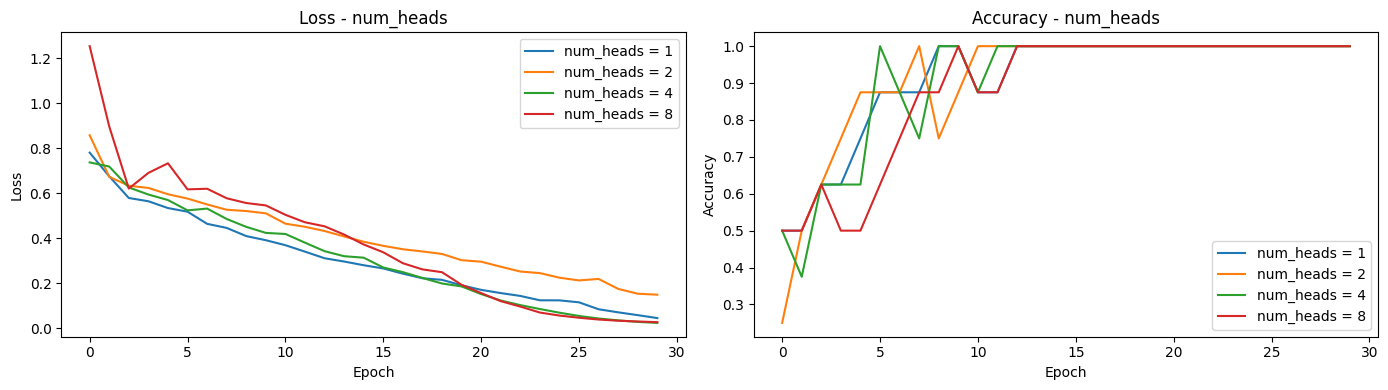

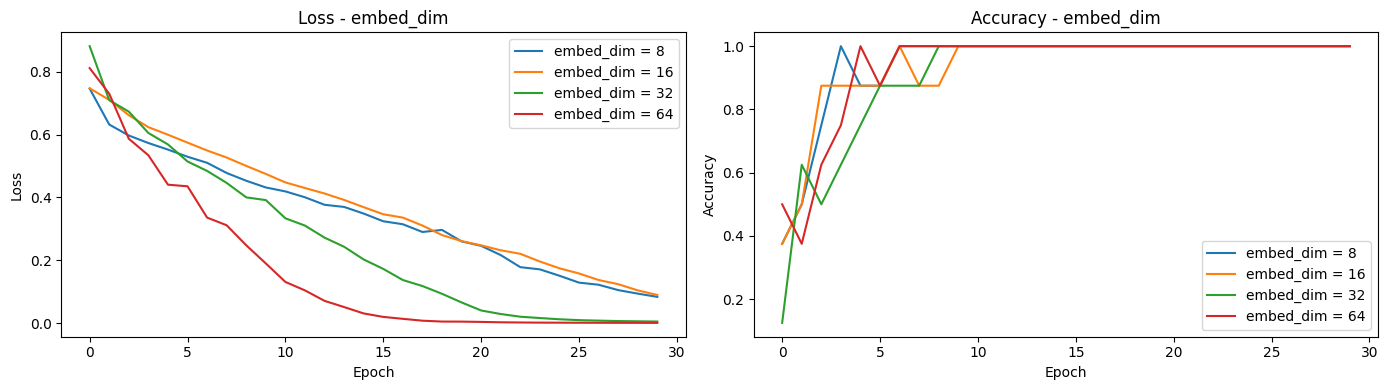

Num Heads    Accuracy     Training Time (s)
---------------------------------------------
1            1.0000       5.50
2            1.0000       4.98
4            1.0000       8.76
8            1.0000       10.32

Embedding Dim   Accuracy     Training Time (s)
---------------------------------------------
8               1.0000       6.02
16              1.0000       9.27
32              1.0000       7.16
64              1.0000       6.15


In [2]:
# Plots - num_heads
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for n, res in results_heads.items():
    axes[0].plot(res["history"]["loss"], label=f"num_heads = {n}")
    axes[1].plot(res["history"]["accuracy"], label=f"num_heads = {n}")
axes[0].set_title("Loss - num_heads"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
axes[1].set_title("Accuracy - num_heads"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()


# Plots - embed_dim
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for emb, res in results_embed.items():
    axes[0].plot(res["history"]["loss"], label=f"embed_dim = {emb}")
    axes[1].plot(res["history"]["accuracy"], label=f"embed_dim = {emb}")
axes[0].set_title("Loss - embed_dim"); axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss"); axes[0].legend()
axes[1].set_title("Accuracy - embed_dim"); axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].legend()
plt.tight_layout(); plt.show()


# Table 1 - num_heads
print(f"{'Num Heads':<12} {'Accuracy':<12} {'Training Time (s)'}")
print("-" * 45)
for n, res in results_heads.items():
    print(f"{n:<12} {res['history']['accuracy'][-1]:<12.4f} {res['time']:.2f}")


# Table 2 - embed_dim
print(f"\n{'Embedding Dim':<15} {'Accuracy':<12} {'Training Time (s)'}")
print("-" * 45)
for emb, res in results_embed.items():
    print(f"{emb:<15} {res['history']['accuracy'][-1]:<12.4f} {res['time']:.2f}")